In [5]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

In [6]:
df = pd.read_csv("../data/processed/master_features.csv"
)

df["Year"] = df["Year"].astype(int)

# Handle whichever temperature-range name exists
if "Temperature_Range" not in df.columns and "Temp_Range" in df.columns:
    df["Temperature_Range"] = df["Temp_Range"]

if "Temp_Range" not in df.columns and "Temperature_Range" in df.columns:
    df["Temp_Range"] = df["Temperature_Range"]

print("Shape:", df.shape)
print("Districts:", df["District"].nunique())
print("Years:", df["Year"].min(), "-", df["Year"].max())

print("\nNDVI QA")
print("Unique NDVI values:", df["NDVI"].nunique())
print("NDVI mean:", round(df["NDVI"].mean(), 6))
print("NDVI std:", round(df["NDVI"].std(), 6))

if df["NDVI"].nunique() <= 1:
    raise ValueError(
        "NDVI still has no variation. "
        "Stop and check Notebook 08 / downstream notebooks."
    )

display(df.head())

Shape: (78, 23)
Districts: 9
Years: 2015 - 2024

NDVI QA
Unique NDVI values: 78
NDVI mean: 0.354498
NDVI std: 0.160637


,State,District,Year,Temperature,Min_Temperature,Max_Temperature,Rainfall,wspd,pres,Forest_Loss,...,District_ID,Temp_Range,Rainfall_per_Elevation,Vegetation_Forest_Index,Temperature_Scaled,Rainfall_Scaled,NDVI_Scaled,Forest_Loss_Scaled,Elevation_Scaled,Temperature_Range
0,Karnataka,Shivamogga,2021,24.506868,13.2,37.2,1779.7,8.926923,1010.807967,0.019144,...,4,24.0,2.621533,0.424327,-1.615758,-1.222850,0.489407,1.282355,1.126707,24.0
1,Karnataka,Shivamogga,2022,24.796006,12.8,37.0,1452.4,9.242424,1010.384298,0.019144,...,4,24.2,2.139414,0.431454,-1.455626,-1.597997,0.534931,1.282355,1.126707,24.2
2,Karnataka,Shivamogga,2023,25.862466,13.0,39.3,751.4,11.691781,1011.566575,0.019144,...,4,26.3,1.106827,0.437099,-0.864994,-2.401474,0.570987,1.282355,1.126707,26.3
3,Karnataka,Shivamogga,2024,25.993820,13.9,41.0,1359.0,10.768820,1010.710112,0.019144,...,4,27.1,2.001834,0.412997,-0.792246,-1.705051,0.417031,1.282355,1.126707,27.1
4,Karnataka,Uttara Kannada,2015,27.601681,20.4,35.5,3006.5,9.943332,1009.976558,0.008988,...,7,15.1,6.975929,0.542703,0.098227,0.183291,1.210040,-0.348361,0.212802,15.1


In [7]:
coverage = (
    df.groupby(
        ["State", "District"]
    )
    .agg(
        Observations=("Year", "count"),
        First_Year=("Year", "min"),
        Last_Year=("Year", "max")
    )
    .reset_index()
)

coverage.to_csv("../paper/tables/table_dataset_coverage.csv",
    index=False
)

display(coverage)

print("Dataset coverage saved.")

,State,District,Observations,First_Year,Last_Year
0,Goa,North Goa,10,2015,2024
1,Goa,South Goa,10,2015,2024
2,Karnataka,Chikkamagaluru,4,2021,2024
3,Karnataka,Kodagu,10,2015,2024
4,Karnataka,Shivamogga,4,2021,2024
5,Karnataka,Uttara Kannada,10,2015,2024
6,Kerala,Kannur,10,2015,2024
7,Kerala,Wayanad,10,2015,2024
8,Maharashtra,Sindhudurg,10,2015,2024


Dataset coverage saved.


In [9]:
missing_report = pd.DataFrame({
    "Missing_Values":
        df.isnull().sum(),

    "Missing_Percentage":
        (
            df.isnull().sum()
            / len(df)
        ) * 100
})

missing_report = missing_report[
    missing_report["Missing_Values"] > 0
]

missing_report.to_csv("../paper/tablestable_missing_values.csv"
)

display(missing_report)

print("Missing-value report saved.")

,Missing_Values,Missing_Percentage


Missing-value report saved.


In [10]:
descriptive_features = [
    "Temperature",
    "Min_Temperature",
    "Max_Temperature",
    "Rainfall",
    "NDVI",
    "Forest_Loss",
    "Elevation",
    "Temperature_Range"
]

descriptive_features = [
    col
    for col in descriptive_features
    if col in df.columns
]

descriptive_stats = (
    df[
        descriptive_features
    ]
    .describe()
    .T
)

descriptive_stats.to_csv("../paper/tables/table_descriptive_statistics.csv"
)

display(
    descriptive_stats.round(4)
)

,count,mean,std,min,25%,50%,75%,max
Temperature,78.0,27.4243,1.8173,20.7486,27.5275,27.9195,28.4028,30.1500
Min_Temperature,78.0,18.2962,2.9240,10.7000,17.0000,18.1000,20.3750,25.4000
Max_Temperature,78.0,36.7064,1.7504,31.8000,36.0500,36.8000,37.1750,42.1000
Rainfall,78.0,2846.5859,878.1052,4.1000,2317.5750,2887.5500,3298.8500,4865.3000
NDVI,78.0,0.3545,0.1606,0.1427,0.1913,0.2892,0.5158,0.6255
Forest_Loss,78.0,0.0112,0.0063,0.0038,0.0047,0.0090,0.0166,0.0211
Elevation,78.0,372.2598,273.0044,71.2226,99.1888,211.3578,651.7235,890.5947
Temperature_Range,78.0,18.4103,3.1986,9.8000,16.3250,18.4500,19.9500,27.1000


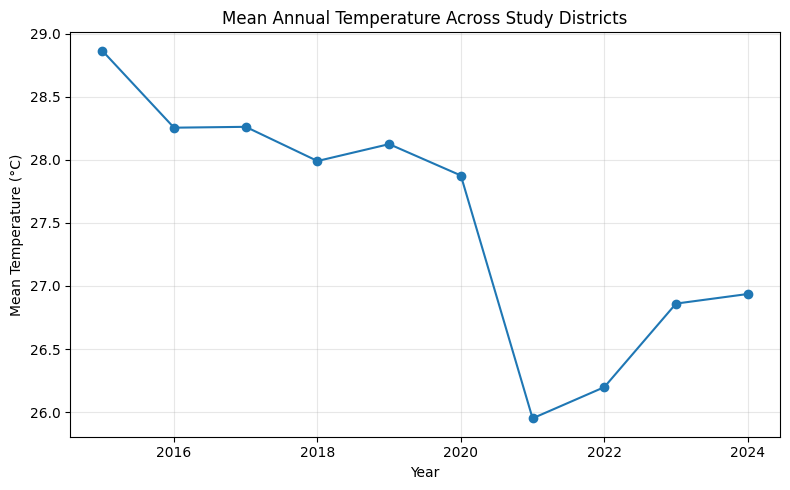

In [11]:
temperature_yearly = (
    df.groupby("Year")["Temperature"]
    .mean()
    .reset_index()
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    temperature_yearly["Year"],
    temperature_yearly["Temperature"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")

plt.title(
    "Mean Annual Temperature Across Study Districts"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../paper/figures/figure_temperature_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

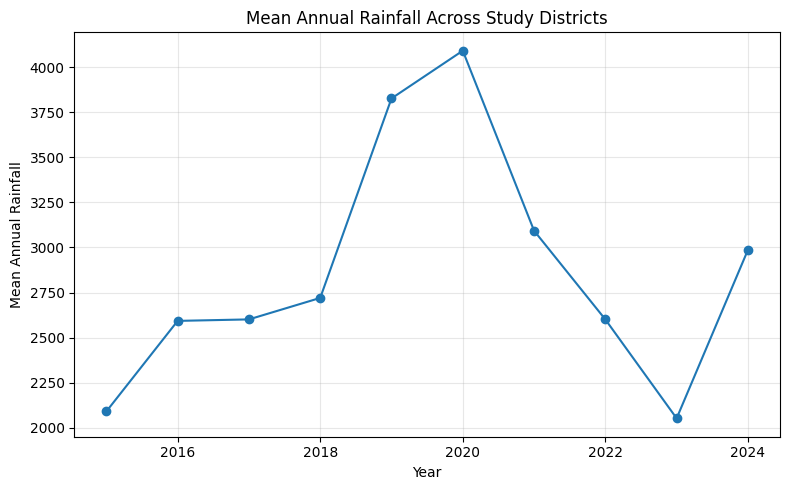

In [12]:
rainfall_yearly = (
    df.groupby("Year")["Rainfall"]
    .mean()
    .reset_index()
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    rainfall_yearly["Year"],
    rainfall_yearly["Rainfall"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean Annual Rainfall")

plt.title(
    "Mean Annual Rainfall Across Study Districts"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../paper/figures/figure_rainfall_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

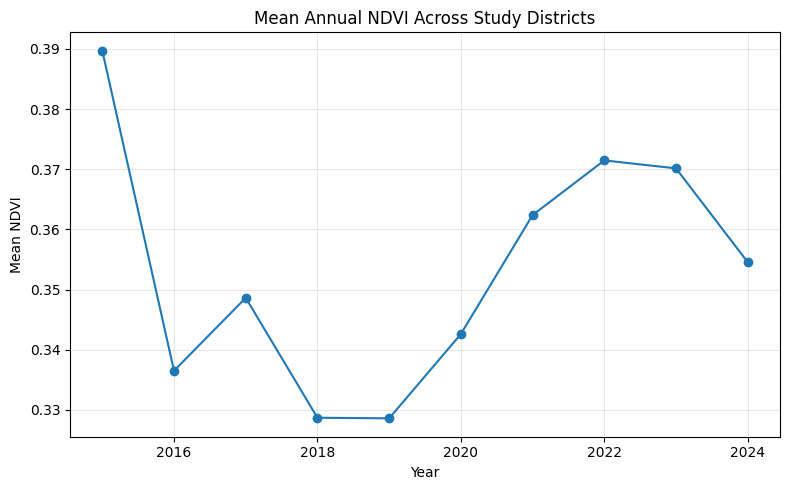

In [13]:
ndvi_yearly = (
    df.groupby("Year")["NDVI"]
    .mean()
    .reset_index()
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    ndvi_yearly["Year"],
    ndvi_yearly["NDVI"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean NDVI")

plt.title(
    "Mean Annual NDVI Across Study Districts"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../paper/figures/figure_ndvi_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

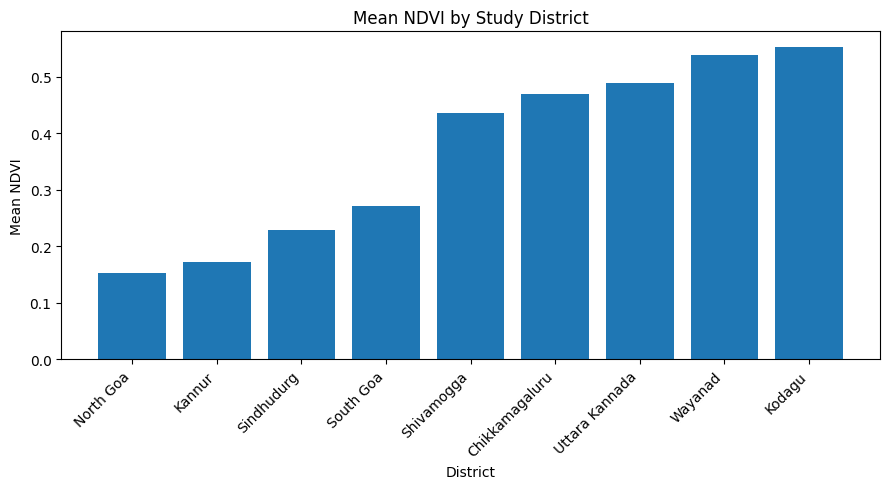

In [14]:
district_ndvi = (
    df.groupby("District")["NDVI"]
    .mean()
    .sort_values()
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    district_ndvi.index,
    district_ndvi.values
)

plt.xlabel("District")
plt.ylabel("Mean NDVI")

plt.title(
    "Mean NDVI by Study District"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_ndvi_by_district.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

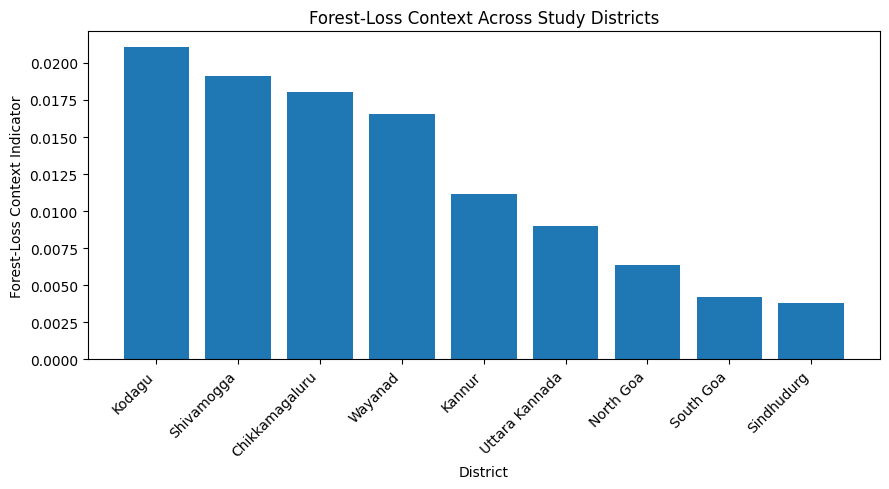

In [15]:
district_forest = (
    df.groupby("District")["Forest_Loss"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    district_forest.index,
    district_forest.values
)

plt.xlabel("District")

plt.ylabel(
    "Forest-Loss Context Indicator"
)

plt.title(
    "Forest-Loss Context Across Study Districts"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_forest_loss_by_district.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

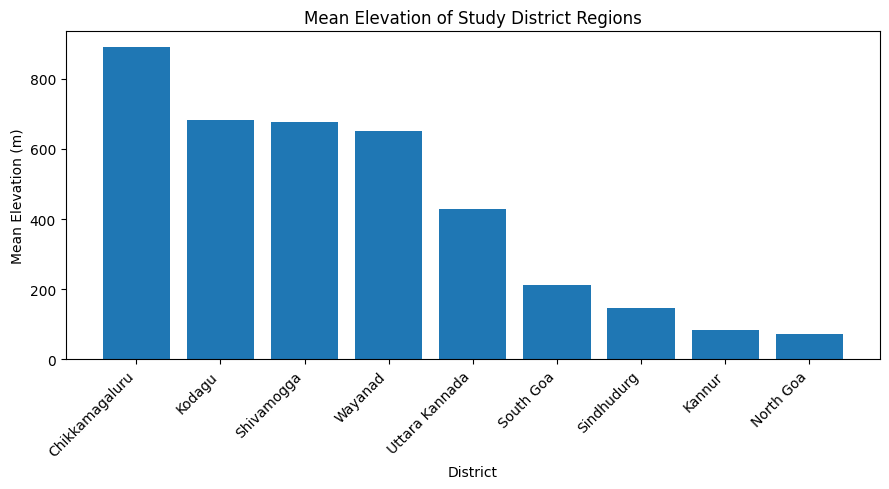

In [16]:
district_elevation = (
    df.groupby("District")["Elevation"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    district_elevation.index,
    district_elevation.values
)

plt.xlabel("District")
plt.ylabel("Mean Elevation (m)")

plt.title(
    "Mean Elevation of Study District Regions"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_elevation_by_district.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

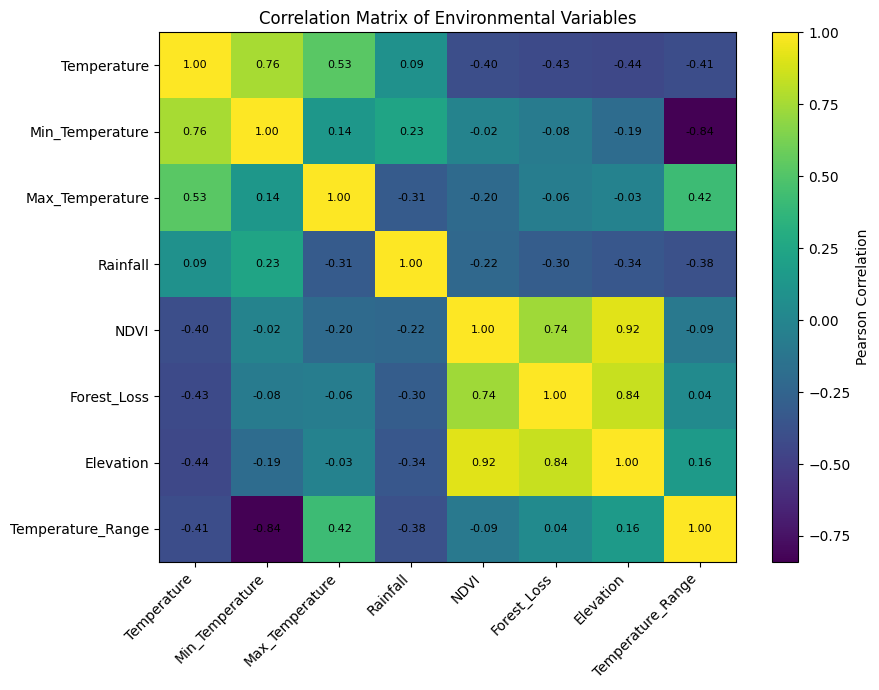

In [17]:
correlation_features = [
    "Temperature",
    "Min_Temperature",
    "Max_Temperature",
    "Rainfall",
    "NDVI",
    "Forest_Loss",
    "Elevation",
    "Temperature_Range"
]

correlation_features = [
    col
    for col in correlation_features
    if col in df.columns
]

corr = df[
    correlation_features
].corr()

fig, ax = plt.subplots(
    figsize=(9, 7)
)

im = ax.imshow(
    corr.values,
    aspect="auto"
)

ax.set_xticks(
    range(
        len(correlation_features)
    )
)

ax.set_yticks(
    range(
        len(correlation_features)
    )
)

ax.set_xticklabels(
    correlation_features,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_features
)

for i in range(
    len(correlation_features)
):

    for j in range(
        len(correlation_features)
    ):

        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(
    im,
    ax=ax,
    label="Pearson Correlation"
)

ax.set_title(
    "Correlation Matrix of Environmental Variables"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

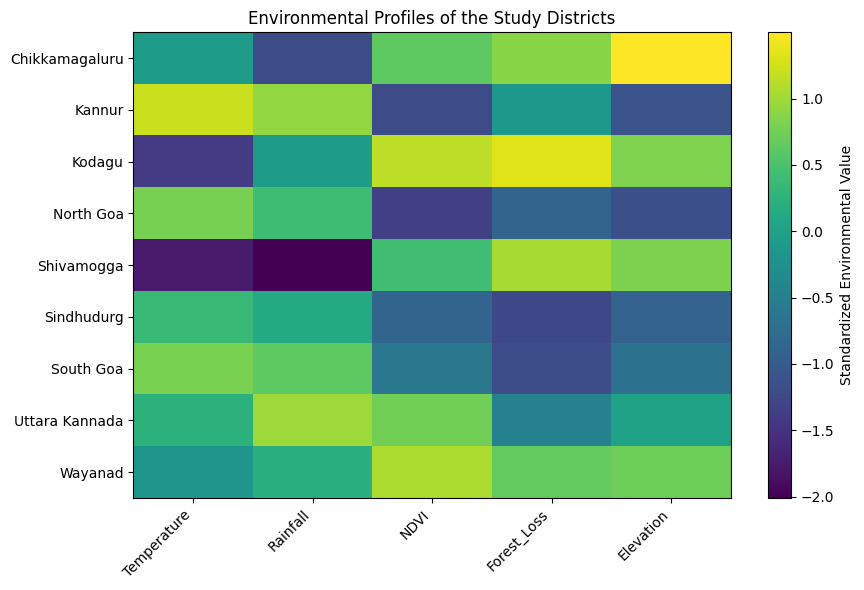

In [18]:
profile_features = [
    "Temperature",
    "Rainfall",
    "NDVI",
    "Forest_Loss",
    "Elevation"
]

district_profile = (
    df.groupby("District")[
        profile_features
    ]
    .mean()
)

profile_std = (
    district_profile
    .std()
    .replace(
        0,
        np.nan
    )
)

normalized_profile = (
    district_profile
    -
    district_profile.mean()
) / profile_std

fig, ax = plt.subplots(
    figsize=(9, 6)
)

im = ax.imshow(
    normalized_profile.values,
    aspect="auto"
)

ax.set_xticks(
    range(
        len(profile_features)
    )
)

ax.set_xticklabels(
    profile_features,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(
        len(normalized_profile.index)
    )
)

ax.set_yticklabels(
    normalized_profile.index
)

fig.colorbar(
    im,
    ax=ax,
    label="Standardized Environmental Value"
)

ax.set_title(
    "Environmental Profiles of the Study Districts"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_district_environment_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
engineered_candidates = [
    "Temperature_Range",
    "Temp_Range",
    "Vegetation_Forest_Index",
    "Rainfall_per_Elevation",
    "Rainfall_Elevation_Index",
    "Climate_Stress_Index",
    "Vegetation_Density"
]

engineered_features = []

for col in engineered_candidates:

    if (
        col in df.columns
        and col not in engineered_features
    ):

        engineered_features.append(
            col
        )


if engineered_features:

    engineered_summary = (
        df[
            engineered_features
        ]
        .describe()
        .T
    )

    engineered_summary.to_csv("../paper/tables/table_engineered_features.csv"
    )

    display(
        engineered_summary.round(4)
    )

else:

    print(
        "No engineered feature columns found."
    )

,count,mean,std,min,25%,50%,75%,max
Temperature_Range,78.0,18.4103,3.1986,9.8000,16.3250,18.4500,19.9500,27.1000
Temp_Range,78.0,18.4103,3.1986,9.8000,16.3250,18.4500,19.9500,27.1000
Vegetation_Forest_Index,78.0,0.3498,0.1570,0.1418,0.1895,0.2880,0.5072,0.6149
Rainfall_per_Elevation,78.0,16.7986,15.5683,0.0060,4.6545,11.0937,24.6572,59.7265


In [20]:
overview = {

    "Total_Observations":
        len(df),

    "States":
        df["State"].nunique(),

    "Districts":
        df["District"].nunique(),

    "First_Year":
        int(
            df["Year"].min()
        ),

    "Last_Year":
        int(
            df["Year"].max()
        ),

    "Environmental_Features":
        len(
            correlation_features
        ),

    "Engineered_Features":
        len(
            engineered_features
        ),

    "Unique_NDVI_Values":
        int(
            df["NDVI"].nunique()
        )
}


overview_df = pd.DataFrame(
    overview.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

overview_df.to_csv("../paper/tables/table_dataset_overview.csv",
    index=False
)

display(
    overview_df
)

,Metric,Value
0,Total_Observations,78
1,States,4
2,Districts,9
3,First_Year,2015
4,Last_Year,2024
5,Environmental_Features,8
6,Engineered_Features,4
7,Unique_NDVI_Values,78


In [22]:
model_results = pd.read_csv("../paper/tables/table_model_comparison_logo.csv"
)

temporal_results = pd.read_csv("../paper/tables/table_temporal_validation.csv"
)

ablation_results = pd.read_csv("../paper/tables/table_feature_set_ablation.csv"
)

final_results = pd.read_csv("../paper/tables/table_final_model_results_v3.csv"
)

oof_predictions = pd.read_csv("../data/processed/model_oof_predictions_final_v3.csv"
)

feature_importance = pd.read_csv("../paper/tables/table_final_model_feature_importance_v3.csv"
)

with open("../outputs/models/kfd_outbreak_model_v3_metadata.json",
    "r",
    encoding="utf-8"
) as f:

    metadata = json.load(f)


print(
    "Corrected V3 ML outputs loaded."
)

print(
    "Final model:",
    metadata["model_name"]
)

print(
    "Model version:",
    metadata["model_version"]
)

print(
    "Validation:",
    metadata["validation"]
)

print(
    "Features:",
    metadata["features"]
)

display(
    final_results.round(3)
)

Corrected V3 ML outputs loaded.
Final model: Dynamic Decision Tree
Model version: v3
Validation: Leave-One-District-Out
Features: ['Temperature', 'Rainfall', 'NDVI', 'Temp_Range']


,Model,Validation,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dynamic Decision Tree V3,Leave-One-District-Out,0.652,0.652,0.652,0.652,0.652,0.519,0.544


In [23]:
expected_n = int(
    metadata["training_observations"]
)

if (
    len(oof_predictions)
    != expected_n
):

    raise ValueError(
        f"OOF rows "
        f"({len(oof_predictions)}) "
        f"do not match "
        f"training observations "
        f"({expected_n})."
    )


required_oof_columns = {
    "True_Label",
    "Predicted_Label",
    "Model_Score"
}

missing_oof = (
    required_oof_columns
    -
    set(
        oof_predictions.columns
    )
)

if missing_oof:

    raise ValueError(
        f"Missing OOF columns: "
        f"{missing_oof}"
    )


print(
    "V3 consistency checks passed."
)

V3 consistency checks passed.


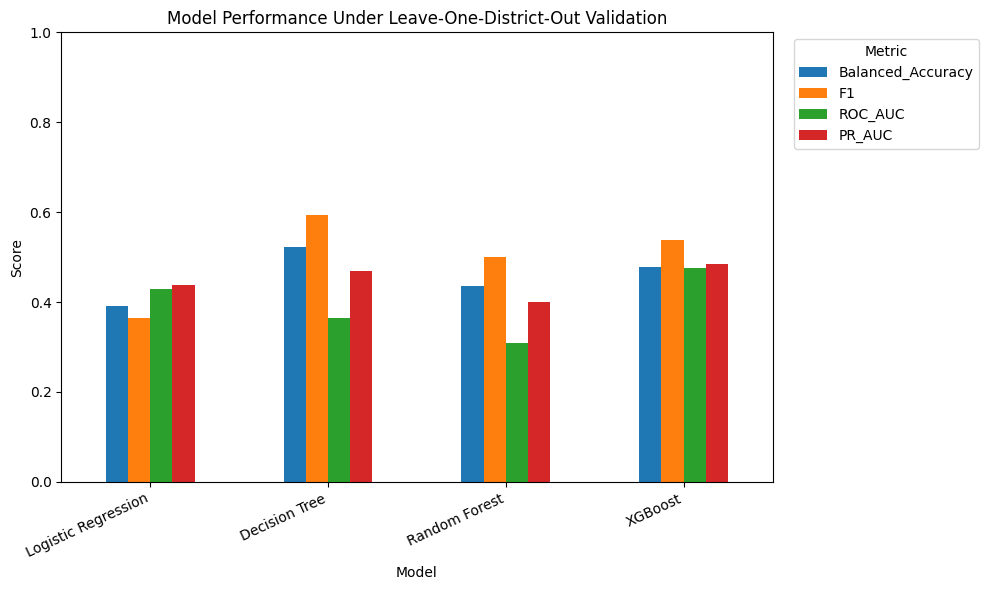

In [24]:
model_order = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]


model_results_ml = (
    model_results[
        model_results["Model"]
        .isin(
            model_order
        )
    ]
    .copy()
)


model_results_ml["Model"] = (
    pd.Categorical(
        model_results_ml["Model"],
        categories=model_order,
        ordered=True
    )
)


model_results_ml = (
    model_results_ml
    .sort_values("Model")
    .reset_index(drop=True)
)


metrics_to_plot = [
    "Balanced_Accuracy",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]


plot_df = (
    model_results_ml[
        ["Model"]
        +
        metrics_to_plot
    ]
    .set_index("Model")
)


ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Model Performance Under "
    "Leave-One-District-Out Validation"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")

ax.set_ylim(
    0,
    1
)

ax.legend(
    title="Metric",
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_spatial_model_comparison_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

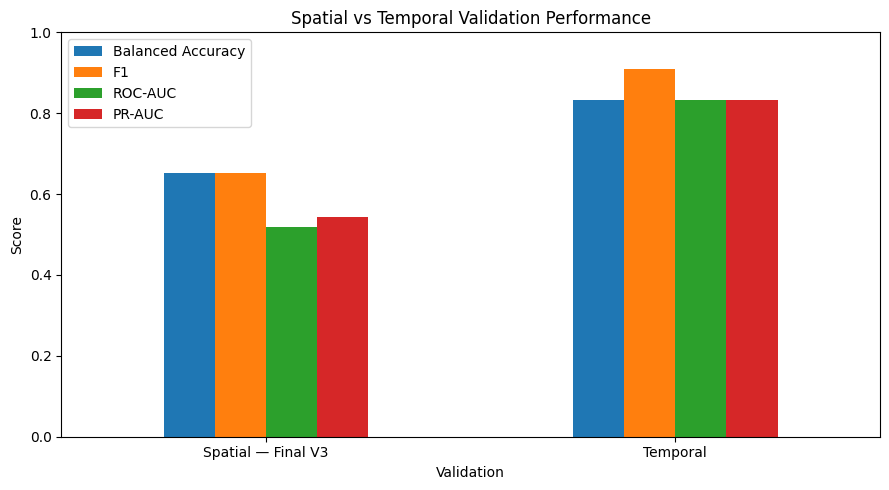

,Validation,Balanced Accuracy,F1,ROC-AUC,PR-AUC
0,Spatial — Final V3,0.652,0.652,0.519,0.544
1,Temporal,0.833,0.909,0.833,0.833


In [25]:
spatial_final = (
    final_results.iloc[0]
)

temporal_dt = (
    temporal_results[
        temporal_results["Model"]
        ==
        "Decision Tree"
    ]
    .iloc[0]
)


comparison = pd.DataFrame({

    "Validation": [
        "Spatial — Final V3",
        "Temporal"
    ],

    "Balanced Accuracy": [
        spatial_final[
            "Balanced_Accuracy"
        ],
        temporal_dt[
            "Balanced_Accuracy"
        ]
    ],

    "F1": [
        spatial_final["F1"],
        temporal_dt["F1"]
    ],

    "ROC-AUC": [
        spatial_final[
            "ROC_AUC"
        ],
        temporal_dt[
            "ROC_AUC"
        ]
    ],

    "PR-AUC": [
        spatial_final[
            "PR_AUC"
        ],
        temporal_dt[
            "PR_AUC"
        ]
    ]
})


comparison.to_csv("../paper/tables/table_spatial_vs_temporal_v3.csv",
    index=False
)


comparison_plot = (
    comparison
    .set_index(
        "Validation"
    )
)


ax = comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Spatial vs Temporal Validation Performance"
)

ax.set_ylabel("Score")

ax.set_ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_spatial_vs_temporal_validation_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(
    comparison.round(3)
)

In [26]:
ablation_sorted = (
    ablation_results
    .sort_values(
        [
            "Feature_Set",
            "Balanced_Accuracy"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


ablation_sorted.to_csv("../paper/tables/table_feature_ablation_final_v3.csv",
    index=False
)


display(
    ablation_sorted.round(3)
)

,Feature_Set,Model,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Combined,Decision Tree,0.522,0.516,0.696,0.593,0.365,0.469
1,Combined,XGBoost,0.478,0.483,0.609,0.538,0.476,0.486
2,Combined,Random Forest,0.435,0.448,0.565,0.500,0.308,0.400
3,Combined,Logistic Regression,0.391,0.381,0.348,0.364,0.429,0.438
4,Dynamic Only,Decision Tree,0.652,0.652,0.652,0.652,0.519,0.544
5,Dynamic Only,Random Forest,0.565,0.552,0.696,0.615,0.465,0.474
6,Dynamic Only,XGBoost,0.522,0.519,0.609,0.560,0.512,0.510
7,Dynamic Only,Logistic Regression,0.500,0.500,0.522,0.511,0.433,0.441
8,Static Only,Decision Tree,0.304,0.345,0.435,0.385,0.208,0.373
9,Static Only,Logistic Regression,0.283,0.333,0.435,0.377,0.342,0.461


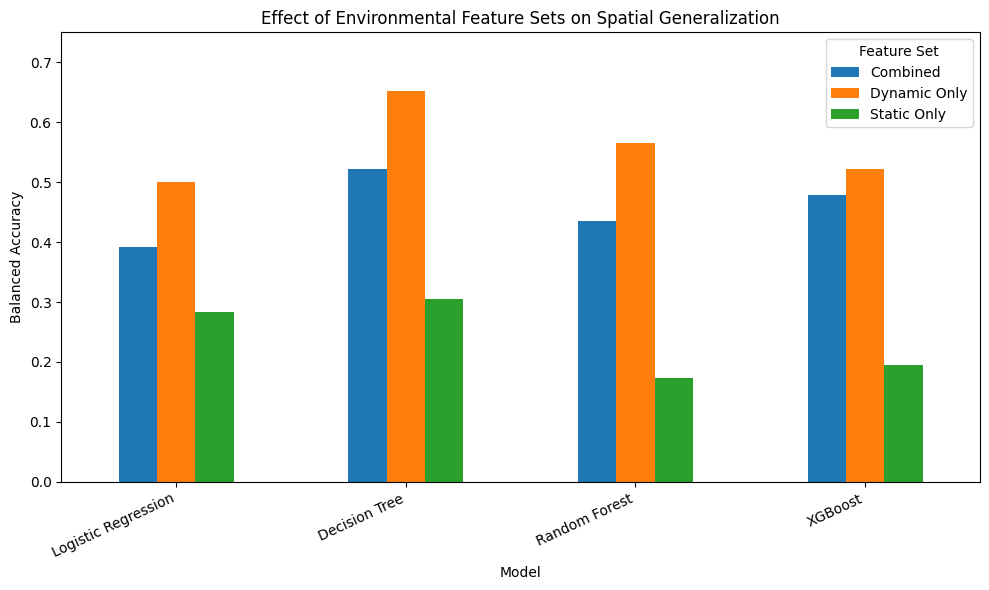

In [27]:
pivot_ablation = (
    ablation_results
    .pivot(
        index="Model",
        columns="Feature_Set",
        values="Balanced_Accuracy"
    )
    .reindex(
        model_order
    )
)


ax = pivot_ablation.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Effect of Environmental Feature Sets "
    "on Spatial Generalization"
)

ax.set_xlabel("Model")

ax.set_ylabel(
    "Balanced Accuracy"
)

ax.set_ylim(
    0,
    0.75
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    title="Feature Set"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_feature_set_ablation_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

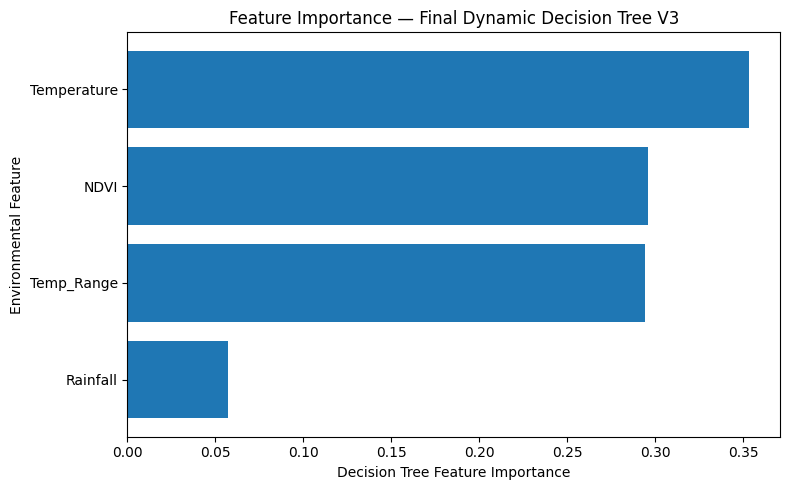

,Feature,Importance
0,Temperature,0.3532
1,NDVI,0.2958
2,Temp_Range,0.2939
3,Rainfall,0.0570


In [28]:
importance_plot = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=True
    )
)


plt.figure(
    figsize=(8, 5)
)

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"]
)

plt.xlabel(
    "Decision Tree Feature Importance"
)

plt.ylabel(
    "Environmental Feature"
)

plt.title(
    "Feature Importance — "
    "Final Dynamic Decision Tree V3"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_final_v3_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


display(
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .round(4)
)

In [29]:
y_true = (
    oof_predictions[
        "True_Label"
    ]
    .astype(int)
)

y_pred = (
    oof_predictions[
        "Predicted_Label"
    ]
    .astype(int)
)

y_score = (
    oof_predictions[
        "Model_Score"
    ]
    .astype(float)
)

print(
    "OOF observations:",
    len(y_true)
)

OOF observations: 46


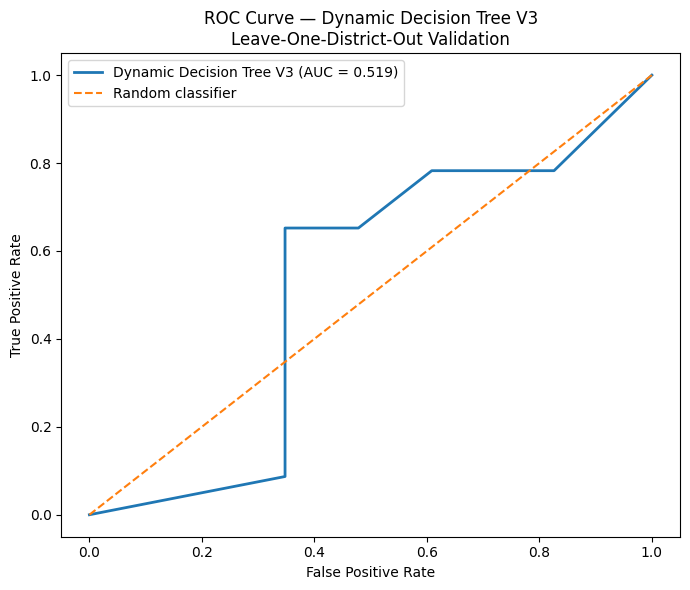

Final V3 spatial ROC-AUC: 0.519


In [30]:
fpr, tpr, _ = (
    roc_curve(
        y_true,
        y_score
    )
)

final_auc = (
    roc_auc_score(
        y_true,
        y_score
    )
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"Dynamic Decision Tree V3 "
        f"(AUC = {final_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Dynamic Decision Tree V3\n"
    "Leave-One-District-Out Validation"
)

plt.legend()

plt.tight_layout()

plt.savefig("../paper/figures/figure_final_v3_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Final V3 spatial ROC-AUC:",
    round(
        final_auc,
        3
    )
)

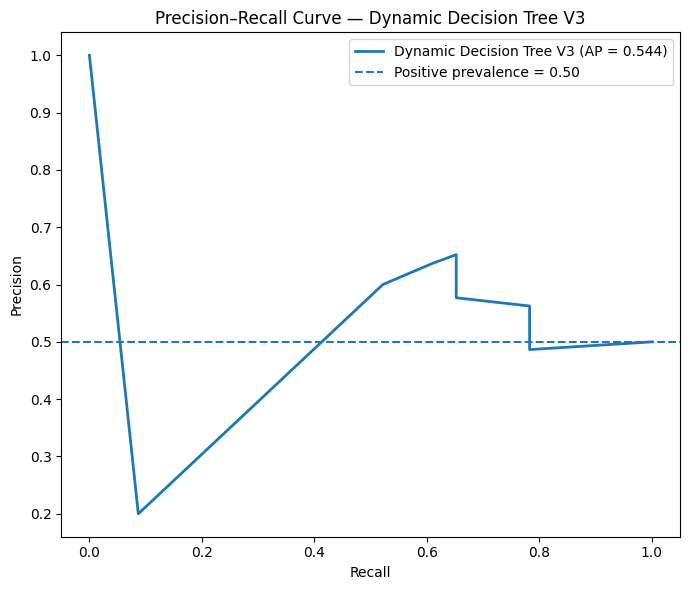

Final V3 PR-AUC / AP: 0.544


In [31]:
precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_true,
        y_score
    )
)

final_pr_auc = (
    average_precision_score(
        y_true,
        y_score
    )
)

baseline = (
    y_true.mean()
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"Dynamic Decision Tree V3 "
        f"(AP = {final_pr_auc:.3f})"
    )
)

plt.axhline(
    baseline,
    linestyle="--",
    label=(
        f"Positive prevalence "
        f"= {baseline:.2f}"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision–Recall Curve — "
    "Dynamic Decision Tree V3"
)

plt.legend()

plt.tight_layout()

plt.savefig("../paper/figures/figure_final_v3_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Final V3 PR-AUC / AP:",
    round(
        final_pr_auc,
        3
    )
)

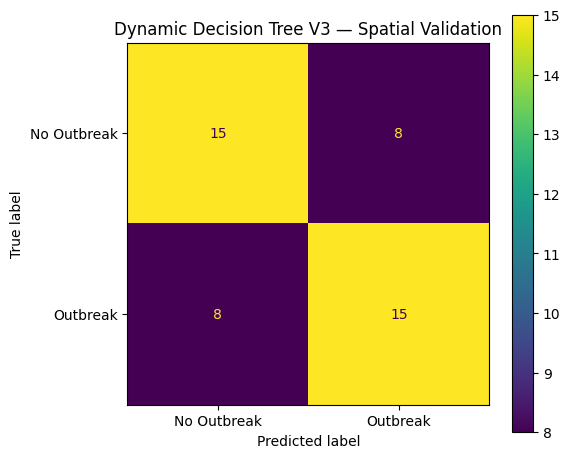

[[15  8]
 [ 8 15]]


In [32]:
cm = confusion_matrix(
    y_true,
    y_pred
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Outbreak",
        "Outbreak"
    ]
)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


disp.plot(
    ax=ax,
    values_format="d"
)


ax.set_title(
    "Dynamic Decision Tree V3 — "
    "Spatial Validation"
)

plt.tight_layout()

plt.savefig("../paper/figures/figure_final_v3_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(cm)

In [33]:
canonical_results = (
    final_results.copy()
)


canonical_results.to_csv("../paper/tables/table_canonical_final_results_v3.csv",
    index=False
)


print(
    "=" * 72
)

print(
    "CANONICAL FINAL V3 RESULTS"
)

print(
    "=" * 72
)


display(
    canonical_results.round(3)
)

CANONICAL FINAL V3 RESULTS


,Model,Validation,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dynamic Decision Tree V3,Leave-One-District-Out,0.652,0.652,0.652,0.652,0.652,0.519,0.544


In [34]:
final_row = (
    canonical_results
    .iloc[0]
)


research_summary = pd.DataFrame({

    "Finding": [

        "Final spatial model",

        "Spatial balanced accuracy",

        "Spatial ROC-AUC",

        "Spatial PR-AUC",

        "Temporal Decision Tree balanced accuracy",

        "Temporal Decision Tree F1",

        "Feature ablation",

        "Dataset size",

        "Class balance",

        "NDVI provenance status"
    ],

    "Result": [

        "Dynamic Decision Tree V3",

        f"{final_row['Balanced_Accuracy']:.3f}",

        f"{final_row['ROC_AUC']:.3f}",

        f"{final_row['PR_AUC']:.3f}",

        f"{temporal_dt['Balanced_Accuracy']:.3f}",

        f"{temporal_dt['F1']:.3f}",

        (
            "Dynamic features outperformed "
            "static-only features"
        ),

        (
            f"{metadata['training_observations']} "
            f"verified observations"
        ),

        (
            f"{metadata['outbreak_observations']} "
            f"outbreak / "
            f"{metadata['non_outbreak_observations']} "
            f"non-outbreak"
        ),

        (
            "Corrected Sentinel-2 "
            "district-year NDVI pipeline"
        )
    ]
})


research_summary.to_csv("../paper/tables/table_research_summary_v3.csv",
    index=False
)


display(
    research_summary
)

,Finding,Result
0,Final spatial model,Dynamic Decision Tree V3
1,Spatial balanced accuracy,0.652
2,Spatial ROC-AUC,0.519
3,Spatial PR-AUC,0.544
4,Temporal Decision Tree balanced accuracy,0.833
5,Temporal Decision Tree F1,0.909
6,Feature ablation,Dynamic features outperformed static-only feat...
7,Dataset size,46 verified observations
8,Class balance,23 outbreak / 23 non-outbreak
9,NDVI provenance status,Corrected Sentinel-2 district-year NDVI pipeline


In [38]:
print(
    "=" * 78
)

print(
    "FINAL RESEARCH PAPER ASSETS — V3 COMPLETE"
)

print(
    "=" * 78
)


print("\nDATASET")
print("-------")

print(
    "Environmental rows:",
    len(df)
)

print(
    "Districts:",
    df["District"].nunique()
)

print(
    "Years:",
    df["Year"].min(),
    "-",
    df["Year"].max()
)

print(
    "Unique NDVI values:",
    df["NDVI"].nunique()
)

print(
    "NDVI mean:",
    round(
        df["NDVI"].mean(),
        6
    )
)

print(
    "NDVI std:",
    round(
        df["NDVI"].std(),
        6
    )
)


print("\nFINAL MODEL")
print("-----------")

print(
    "Model:",
    metadata["model_name"]
)

print(
    "Version:",
    metadata["model_version"]
)

print(
    "Training observations:",
    metadata["training_observations"]
)

print(
    "Validation:",
    metadata["validation"]
)

print(
    "Features:",
    metadata["features"]
)


print(
    "\nCANONICAL FINAL V3 RESULTS"
)

print(
    "--------------------------"
)

display(
    canonical_results.round(3)
)


print(
    "\nFINAL V3 FEATURE IMPORTANCE"
)

print(
    "---------------------------"
)

display(
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .round(4)
)


print("\nV3 FIGURES")
print("----------")

for filename in sorted(
    os.listdir(
        "../paper/figures"
    )
):

    if "_v3" in filename:

        print(
            " -",
            filename
        )


print("\nV3 TABLES")
print("---------")

for filename in sorted(
    os.listdir(
        "../paper/tables"
    )
):

    if "_v3" in filename:

        print(
            " -",
            filename
        )


print(
    "\nNotebook 17 V3 complete."
)

FINAL RESEARCH PAPER ASSETS — V3 COMPLETE

DATASET
-------
Environmental rows: 78
Districts: 9
Years: 2015 - 2024
Unique NDVI values: 78
NDVI mean: 0.354498
NDVI std: 0.160637

FINAL MODEL
-----------
Model: Dynamic Decision Tree
Version: v3
Training observations: 46
Validation: Leave-One-District-Out
Features: ['Temperature', 'Rainfall', 'NDVI', 'Temp_Range']

CANONICAL FINAL V3 RESULTS
--------------------------


,Model,Validation,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dynamic Decision Tree V3,Leave-One-District-Out,0.652,0.652,0.652,0.652,0.652,0.519,0.544



FINAL V3 FEATURE IMPORTANCE
---------------------------


,Feature,Importance
0,Temperature,0.3532
1,NDVI,0.2958
2,Temp_Range,0.2939
3,Rainfall,0.0570



V3 FIGURES
----------
 - figure_feature_set_ablation_v3.png
 - figure_final_v3_confusion_matrix.png
 - figure_final_v3_feature_importance.png
 - figure_final_v3_precision_recall.png
 - figure_final_v3_roc.png
 - figure_spatial_model_comparison_v3.png
 - figure_spatial_vs_temporal_validation_v3.png

V3 TABLES
---------
 - table_canonical_final_results_v3.csv
 - table_feature_ablation_final_v3.csv
 - table_final_model_feature_importance_v3.csv
 - table_final_model_results_v3.csv
 - table_research_summary_v3.csv
 - table_spatial_vs_temporal_v3.csv

Notebook 17 V3 complete.
